# Prévision du Niveau du Réservoir — WADI

**Auteur:** Mohammad Diab – Master IA – Université Clermont Auvergne
**Dataset:** WADI_14days_new.csv — 14 jours, 1 mesure/minute, 129 variables SCADA

-------------------------------------------------------------------

## Table des Matières

1. **Présentation et Contexte** — target, familles variables
2. **Analyse Univariée**
3. **Analyse Bivariée** — corrélations
4. **Feature Engineering** — lags, target t+10
5. **Modélisation** — Persistence, Random Forest, XGBoost
6. **Évaluation** — MAE/RMSE, tableau prédictions, graphiques
7. **Conclusions** — sauvegarde du modèle

----------------------------------------------------------------------


## 1. Présentation et Contexte

### 1.1 Problématique

WADI est un banc d'essai réel de distribution d'eau. Chaque minute, le SCADA enregistre le niveau des réservoirs, les débits, l'état des pompes et des vannes, la pression, etc.

L'objectif du projet : **prédire le niveau du réservoir principal (`2_LT_001_PV`) dans 10 minutes** — pour anticiper un débordement ou un niveau trop bas.

### 1.2 Objectifs

- Comprendre les données WADI (129 variables, 14 jours)
- Identifier les variables utiles pour la prédiction
- Comparer Persistence, Random Forest et XGBoost
- Battre la baseline Persistence d'environ 20 % en RMSE

### 1.3 La variable cible

Le guide cite le pattern SCADA **`1-2-3_LT_001-2_PV`** (niveau des réservoirs, zones 1, 2 ou 3).

| Partie | Signification |
|--------|---------------|
| `1-2-3` | Zone du procédé (1, 2 ou 3) |
| `LT` | Level Transmitter (transmetteur de niveau) |
| `001-2` | Capteur 001 ou 002 |
| `PV` | Process Value (valeur mesurée) |

Dans notre CSV, on retient **`2_LT_001_PV`** (réservoir principal, zone 2, ~70 %). C'est une instance valide du pattern guide.

### 1.4 Type de problème

Forecasting multivarié temporel en **régression** : on utilise les variables SCADA pour prédire **`2_LT_001_PV` à +10 minutes**.


In [1]:
# ============================================================
# CONFIGURATION ET IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Constantes du projet
DATA_PATH = "WADI_14days_new.csv"
TARGET = "2_LT_001_PV"
HORIZON = 10          # minutes (horizon principal)
LAGS = [1, 2, 5, 10]  # lags en minutes
TRAIN_RATIO = 0.8

# Style graphique
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

COLORS = {
    "primary": "#2E86AB",
    "secondary": "#A23B72",
    "success": "#1B998B",
    "warning": "#F18F01",
    "danger": "#C73E1D",
}

print(f"Target: {TARGET} | Horizon: {HORIZON} min | Dataset: {DATA_PATH}")

Target: 2_LT_001_PV | Horizon: 10 min | Dataset: WADI_14days_new.csv


### 1.5 Chargement et Exploration Initiale

In [2]:
df = pd.read_csv(DATA_PATH)

# WADI : Date mixte (9/25/2017 ou 10/2/17) + Time peut dépasser 23:59
# Ex. 24:00 = lendemain 00:00, 47:58 = +47h58 depuis minuit de Date
base = pd.to_datetime(df["Date"], format="mixed")
time_str = df["Time"].astype(str).str.replace(r"\.0$", "", regex=True)
hours = time_str.str.split(":", expand=True)[0].astype(int)
minutes = time_str.str.split(":", expand=True)[1].astype(int)
df["datetime"] = base + pd.to_timedelta(hours * 60 + minutes, unit="m")

df = df.sort_values("datetime").reset_index(drop=True)

print("=" * 60)
print("APERÇU DU DATASET")
print("=" * 60)
print(f"Dimensions: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Période: {df['datetime'].min()} → {df['datetime'].max()}")
print("Fréquence: 1 minute")
print(f"Nombre de variables: {df.shape[1]}")
df.head()

APERÇU DU DATASET
Dimensions: 784,571 lignes × 131 colonnes
Période: 2017-09-25 00:00:00 → 2017-10-09 11:59:00
Fréquence: 1 minute
Nombre de variables: 131


,Row,Date,Time,1_AIT_001_PV,1_AIT_002_PV,1_AIT_003_PV,1_AIT_004_PV,1_AIT_005_PV,1_FIT_001_PV,1_LS_001_AL,...,3_MV_002_STATUS,3_MV_003_STATUS,3_P_001_STATUS,3_P_002_STATUS,3_P_003_STATUS,3_P_004_STATUS,LEAK_DIFF_PRESSURE,PLANT_START_STOP_LOG,TOTAL_CONS_REQUIRED_FLOW,datetime
0,1,9/25/2017,00:00.0,171.155,0.619473,11.5759,504.645,0.318319,0.001157,0,...,1,1,1,1,1,1,67.9651,1,0.68,2017-09-25
1,3601,9/25/2017,00:00.0,169.541,0.583477,11.6411,497.915,0.234815,0.001091,0,...,1,1,1,1,1,1,63.5548,1,0.69,2017-09-25
2,7201,9/25/2017,00:00.0,169.144,0.661469,11.5945,491.584,0.241313,1.905650,0,...,1,1,1,1,1,1,62.7697,1,0.65,2017-09-25
3,18001,9/25/2017,00:00.0,167.540,0.589479,11.6068,505.997,0.331395,0.001139,0,...,1,1,1,1,1,1,59.5263,1,0.09,2017-09-25
4,10801,9/25/2017,00:00.0,169.085,0.595476,11.6187,504.454,0.318423,0.001124,0,...,1,1,1,1,1,1,60.3435,1,0.35,2017-09-25


In [3]:
df.info()

numeric_cols = df.select_dtypes(include=[np.number]).columns
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns

print("\n" + "=" * 60)
print("TYPES DE COLONNES")
print("=" * 60)
print(f"Colonnes numériques: {len(numeric_cols)}")
print(f"Colonnes non numériques: {len(non_numeric_cols)}")
if len(non_numeric_cols) > 0:
    print(f"Exemples non numériques: {list(non_numeric_cols[:5])}")

<class 'pandas.DataFrame'>
RangeIndex: 784571 entries, 0 to 784570
Columns: 131 entries, Row to datetime
dtypes: datetime64[us](1), float64(71), int64(57), str(2)
memory usage: 784.1 MB

TYPES DE COLONNES
Colonnes numériques: 128
Colonnes non numériques: 3
Exemples non numériques: ['Date', 'Time', 'datetime']


### Nettoyage des données — Valeurs manquantes

Avec **129 variables**, on ne peut pas tout afficher dans un seul graphique. On commence par un tableau complet, puis un graphique des **20 variables les plus manquantes**.

Variables avec valeurs manquantes: 8 / 131
Total de valeurs manquantes: 3,138,318

Top 10 variables les plus manquantes:


,Variable,Manquants,Pourcentage
2_P_001_STATUS,2_P_001_STATUS,784571,100.0
2_LS_001_AL,2_LS_001_AL,784571,100.0
2_LS_002_AL,2_LS_002_AL,784571,100.0
2_P_002_STATUS,2_P_002_STATUS,784571,100.0
1_AIT_002_PV,1_AIT_002_PV,12,0.0
1_AIT_004_PV,1_AIT_004_PV,6,0.0
2B_AIT_004_PV,2B_AIT_004_PV,10,0.0
3_AIT_004_PV,3_AIT_004_PV,6,0.0


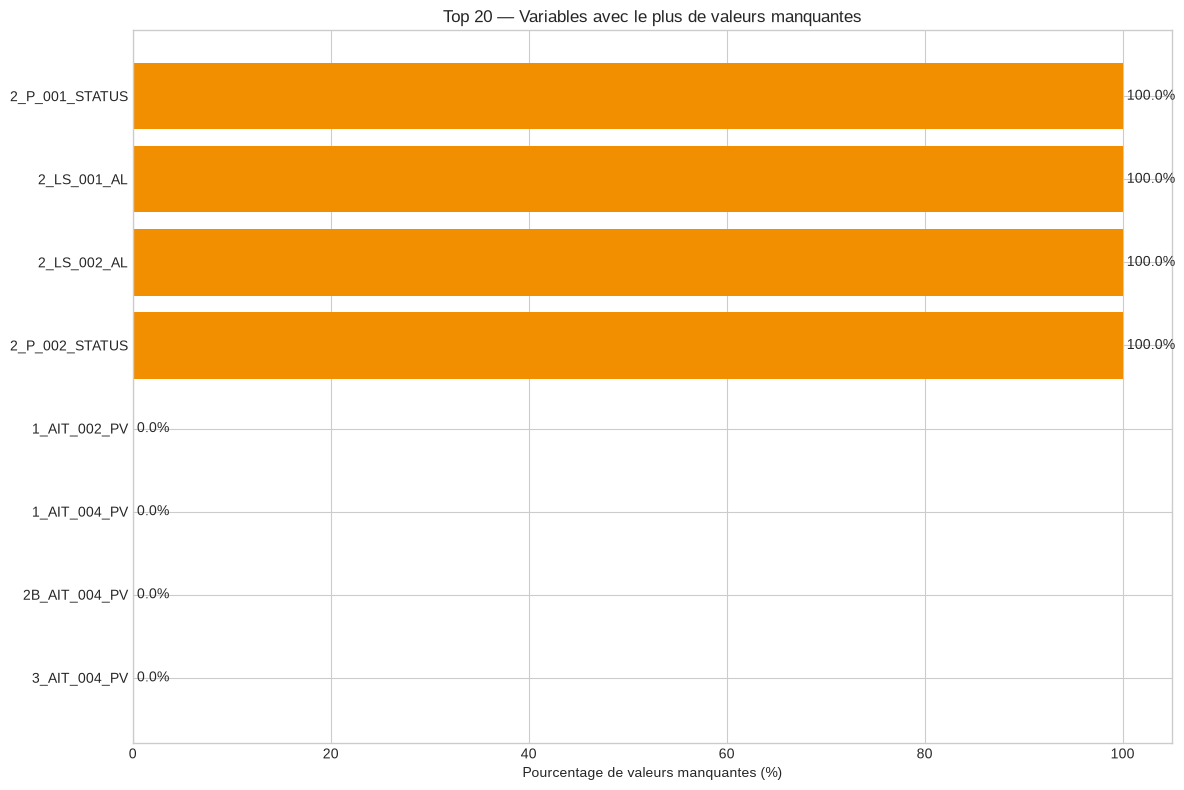

In [4]:
missing = pd.DataFrame({
    "Variable": df.columns,
    "Manquants": df.isnull().sum(),
    "Pourcentage": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("Pourcentage", ascending=False)

missing_only = missing[missing["Manquants"] > 0]
print(f"Variables avec valeurs manquantes: {len(missing_only)} / {len(df.columns)}")
print(f"Total de valeurs manquantes: {missing['Manquants'].sum():,}")
print("\nTop 10 variables les plus manquantes:")
display(missing_only.head(10))

# Graphique : top 20 variables les plus manquantes
top_missing = missing_only.head(20)
if len(top_missing) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.barh(top_missing["Variable"], top_missing["Pourcentage"], color=COLORS["warning"])
    ax.set_xlabel("Pourcentage de valeurs manquantes (%)")
    ax.set_title("Top 20 — Variables avec le plus de valeurs manquantes")
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Aucune valeur manquante détectée.")

In [5]:
print("=" * 60)
print("TRAITEMENT DES VALEURS MANQUANTES")
print("=" * 60)
print(f"Avant imputation — lignes: {len(df):,} | NaN total: {df.isnull().sum().sum():,}")

# Imputation par médiane pour les colonnes numériques (on préserve l'ordre temporel)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print(f"Après imputation — lignes: {len(df):,} | NaN restants: {df.isnull().sum().sum():,}")

TRAITEMENT DES VALEURS MANQUANTES
Avant imputation — lignes: 784,571 | NaN total: 3,138,318
Après imputation — lignes: 784,571 | NaN restants: 3,138,284


### Classification des 129 variables par famille WADI

Les noms de colonnes suivent une convention SCADA (préfixes AIT, FIT, LT, MV, P, etc.). On regroupe les variables par famille pour mieux comprendre la structure du dataset.

> **Note :** l'importance de chaque variable sera confirmée après entraînement (section 6).

CLASSIFICATION DES VARIABLES PAR FAMILLE


,Famille,Nombre,Exemples
0,MV,20,"1_MV_001_STATUS, 1_MV_002_STATUS, 1_MV_003_STA..."
1,AIT,18,"1_AIT_001_PV, 1_AIT_002_PV, 1_AIT_003_PV..."
2,FIC,18,"2_FIC_101_CO, 2_FIC_101_PV, 2_FIC_101_SP..."
3,LS,17,"1_LS_001_AL, 1_LS_002_AL, 2_LS_001_AL..."
4,P_,17,"1_P_001_STATUS, 1_P_002_STATUS, 1_P_003_STATUS..."
5,MCV,7,"2_MCV_007_CO, 2_MCV_101_CO, 2_MCV_201_CO..."
6,Autre,6,"Row, Date, Time..."
7,FQ,6,"2_FQ_101_PV, 2_FQ_201_PV, 2_FQ_301_PV..."
8,SV,6,"2_SV_101_STATUS, 2_SV_201_STATUS, 2_SV_301_STA..."
9,FIT,5,"1_FIT_001_PV, 2_FIT_001_PV, 2_FIT_002_PV..."


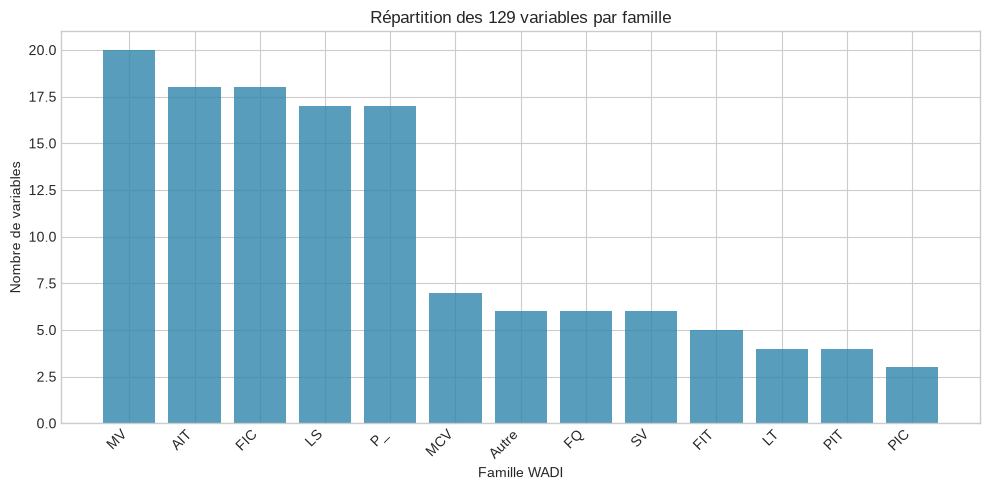

In [6]:
def classify_column(col):
    prefixes = ["AIT", "FIT", "LT", "LS", "MV", "FIC", "PIC", "PIT", "DPIT", "FQ", "MCV", "SV", "P_"]
    for prefix in prefixes:
        if prefix in col:
            return prefix
    return "Autre"

classification = df.columns.to_series().apply(classify_column).value_counts().reset_index()
classification.columns = ["Famille", "Nombre"]

# Tableau avec exemples par famille
examples = []
for famille in classification["Famille"]:
    cols = [c for c in df.columns if classify_column(c) == famille]
    examples.append(", ".join(cols[:3]) + ("..." if len(cols) > 3 else ""))

classification["Exemples"] = examples

print("=" * 60)
print("CLASSIFICATION DES VARIABLES PAR FAMILLE")
print("=" * 60)
display(classification)

# Graphique récapitulatif
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(classification["Famille"], classification["Nombre"], color=COLORS["primary"], alpha=0.8)
ax.set_xlabel("Famille WADI")
ax.set_ylabel("Nombre de variables")
ax.set_title("Répartition des 129 variables par famille")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Section 1 terminée.** Prochaine étape : Analyse Univariée (section 2).

L'importance fine des variables sera confirmée après entraînement (tableau de prédictions, section 6).

---

## 2. Analyse Univariée

On regarde comment se distribue le niveau du réservoir et quelques variables clés.

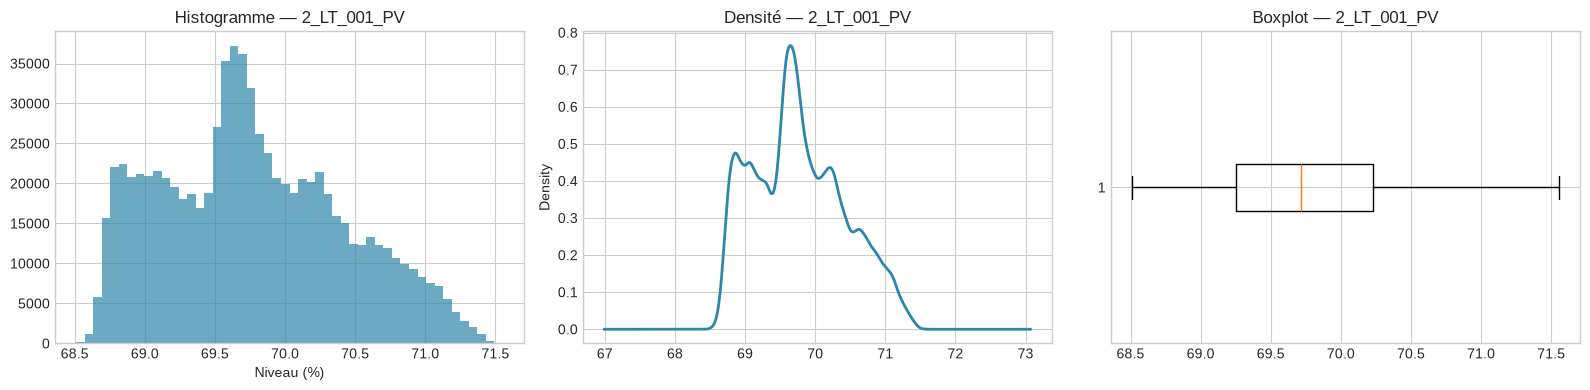

Moyenne: 69.77 | Médiane: 69.71 | Std: 0.65


In [7]:
# Distribution du niveau (target)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df[TARGET].dropna(), bins=50, color=COLORS["primary"], alpha=0.7)
axes[0].set_title(f"Histogramme — {TARGET}")
axes[0].set_xlabel("Niveau (%)")

df[TARGET].plot(kind="kde", ax=axes[1], color=COLORS["primary"], linewidth=2)
axes[1].set_title(f"Densité — {TARGET}")

axes[2].boxplot(df[TARGET].dropna(), vert=False)
axes[2].set_title(f"Boxplot — {TARGET}")

plt.tight_layout()
plt.show()

print(f"Moyenne: {df[TARGET].mean():.2f} | Médiane: {df[TARGET].median():.2f} | Std: {df[TARGET].std():.2f}")

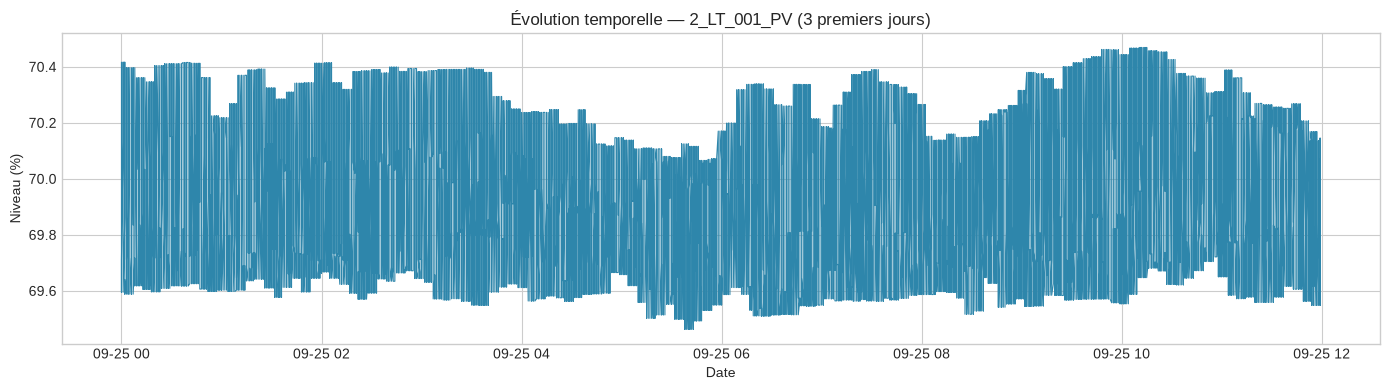

In [8]:
# Série temporelle du niveau (échantillon : 3 premiers jours)
sample = df.iloc[:3 * 24 * 60]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample["datetime"], sample[TARGET], linewidth=0.8, color=COLORS["primary"])
ax.set_title(f"Évolution temporelle — {TARGET} (3 premiers jours)")
ax.set_xlabel("Date")
ax.set_ylabel("Niveau (%)")
plt.tight_layout()
plt.show()

In [9]:
def plot_variable_analysis(series, xlabel, color, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].hist(series.dropna(), bins=50, color=color, alpha=0.7)
    axes[0].set_title(f"Histogramme — {title}")
    axes[0].set_xlabel(xlabel)
    series.plot(kind="kde", ax=axes[1], color=color, linewidth=2)
    axes[1].set_title(f"Densité — {title}")
    axes[2].boxplot(series.dropna(), vert=False)
    axes[2].set_title(f"Boxplot — {title}")
    plt.tight_layout()
    plt.show()
    print(f"Moyenne: {series.mean():.2f} | Médiane: {series.median():.2f} | Std: {series.std():.2f}")

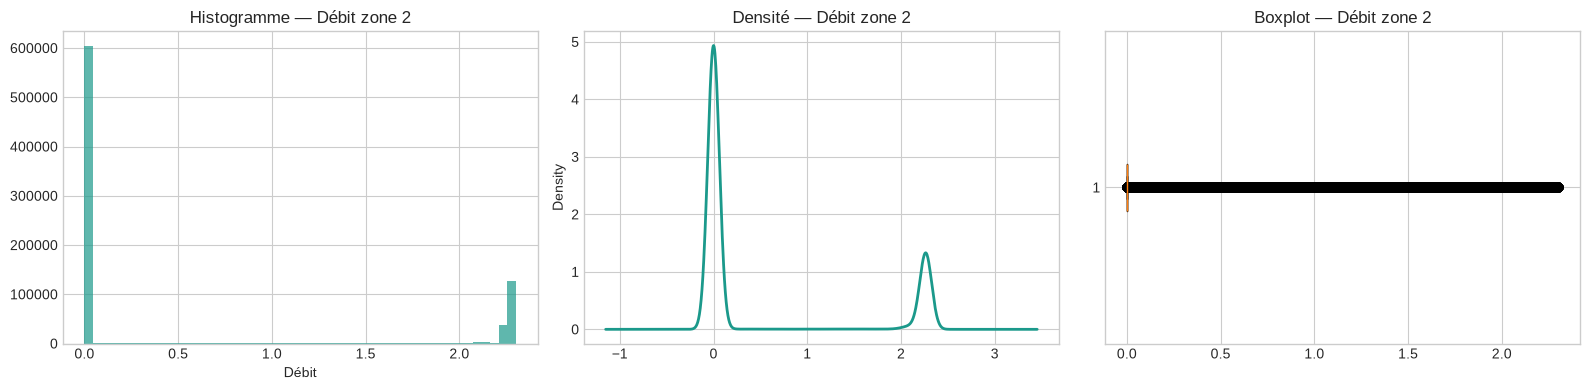

Moyenne: 0.51 | Médiane: 0.00 | Std: 0.94


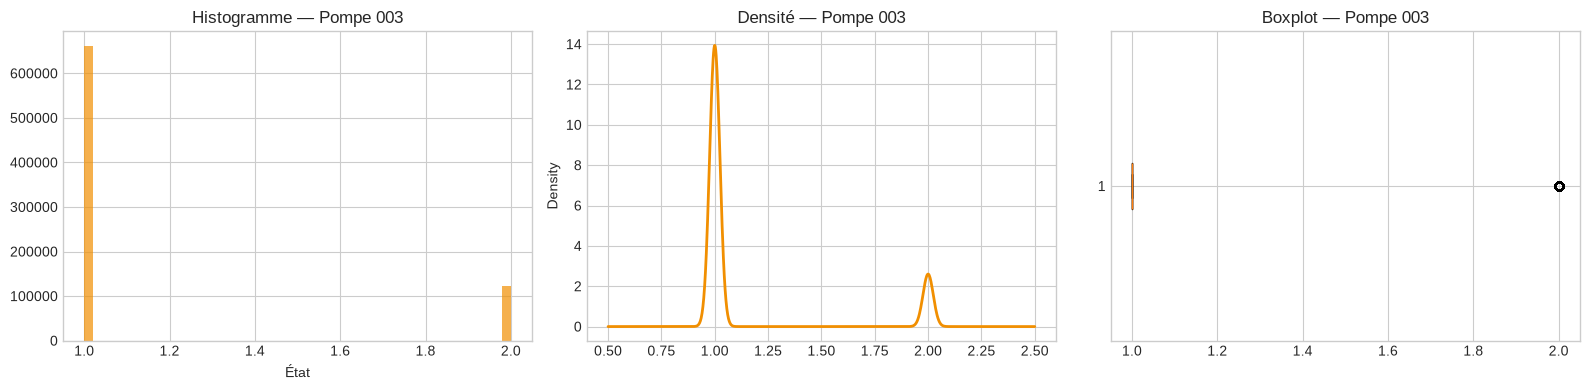

Moyenne: 1.16 | Médiane: 1.00 | Std: 0.36


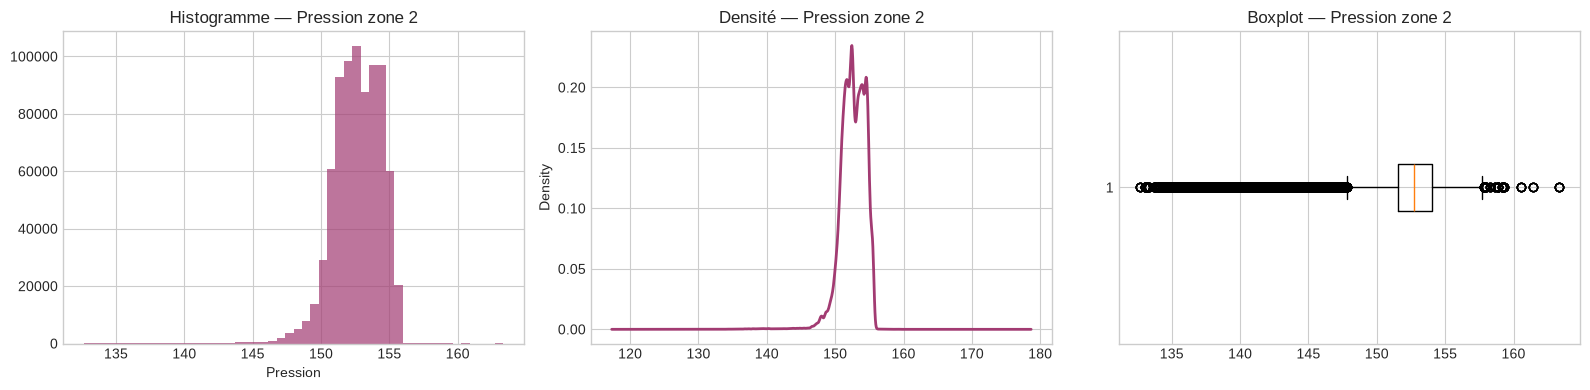

Moyenne: 152.62 | Médiane: 152.69 | Std: 1.87


In [10]:
# Variables clés représentatives des familles principales
key_vars = [
    ("2_FIT_001_PV", "Débit", COLORS["success"], "Débit zone 2"),
    ("2_P_003_STATUS", "État", COLORS["warning"], "Pompe 003"),
    ("2_PIT_001_PV", "Pression", COLORS["secondary"], "Pression zone 2"),
]

for col, xlabel, color, title in key_vars:
    plot_variable_analysis(df[col], xlabel, color, title)

## 3. Analyse Bivariée

On calcule quelles variables bougent avec le niveau du réservoir, pour préparer le choix des features.

In [11]:
# Corrélations avec la target (colonnes numériques uniquement)
exclude_cols = ["Row", TARGET]
numeric_for_corr = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

correlations = df[numeric_for_corr + [TARGET]].corr()[TARGET].drop(TARGET)
correlations = correlations.sort_values(key=abs, ascending=False)

# Top 20 avec famille
top_corr = correlations.head(20).reset_index()
top_corr.columns = ["Variable", "Corrélation"]
top_corr["Famille"] = top_corr["Variable"].apply(classify_column)

print("=" * 60)
print("TOP 20 — CORRÉLATIONS AVEC LA TARGET")
print("=" * 60)
display(top_corr)

TOP 20 — CORRÉLATIONS AVEC LA TARGET


,Variable,Corrélation,Famille
0,2_FIC_301_SP,0.495859,FIC
1,2_FIC_501_SP,0.474286,FIC
2,1_AIT_001_PV,0.470940,AIT
3,1_AIT_002_PV,-0.455105,AIT
4,2_FIC_401_SP,0.442160,FIC
5,2A_AIT_001_PV,0.436224,AIT
6,2_FIC_601_SP,0.416105,FIC
7,2_FIC_101_SP,0.415818,FIC
8,1_AIT_003_PV,-0.395130,AIT
9,2_FIC_201_SP,0.345854,FIC


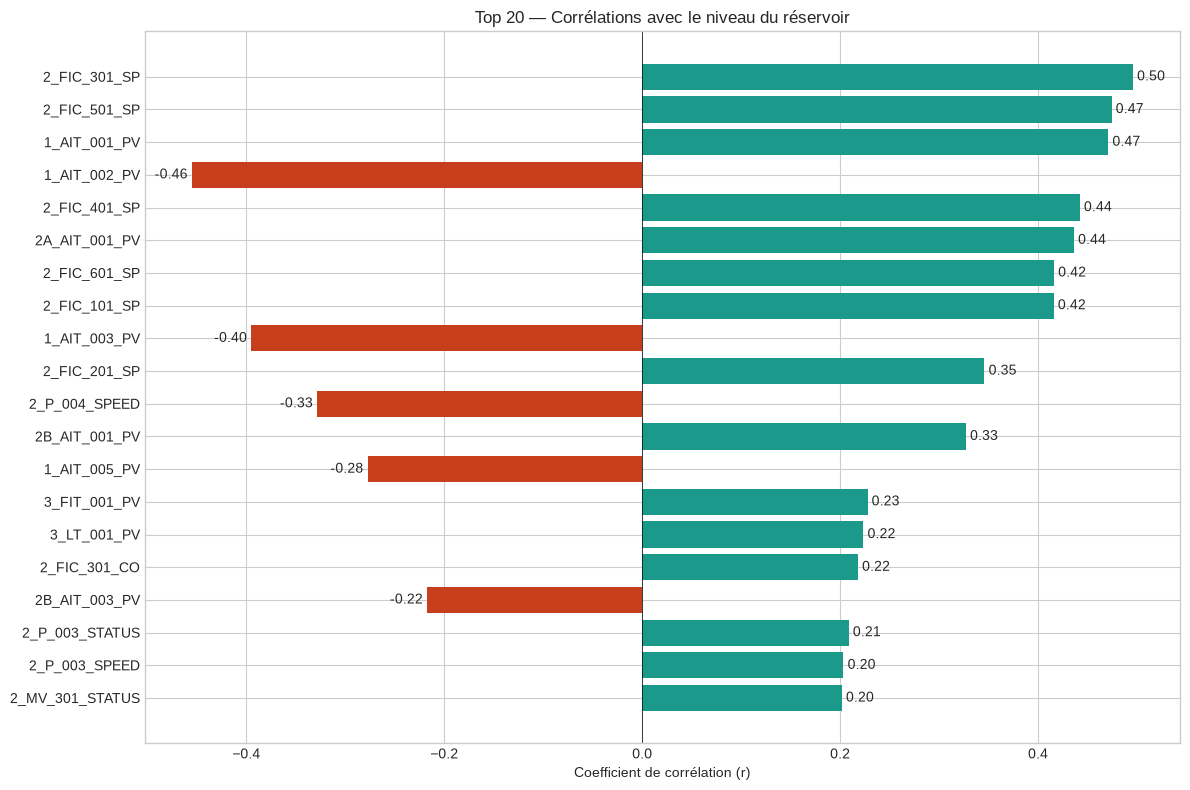

In [12]:
# Graphique des 20 plus fortes corrélations
fig, ax = plt.subplots(figsize=(12, 8))
colors_bar = [COLORS["success"] if c > 0 else COLORS["danger"] for c in top_corr["Corrélation"]]
bars = ax.barh(top_corr["Variable"], top_corr["Corrélation"], color=colors_bar)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Coefficient de corrélation (r)")
ax.set_title("Top 20 — Corrélations avec le niveau du réservoir")
ax.bar_label(bars, fmt="%.2f", padding=3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

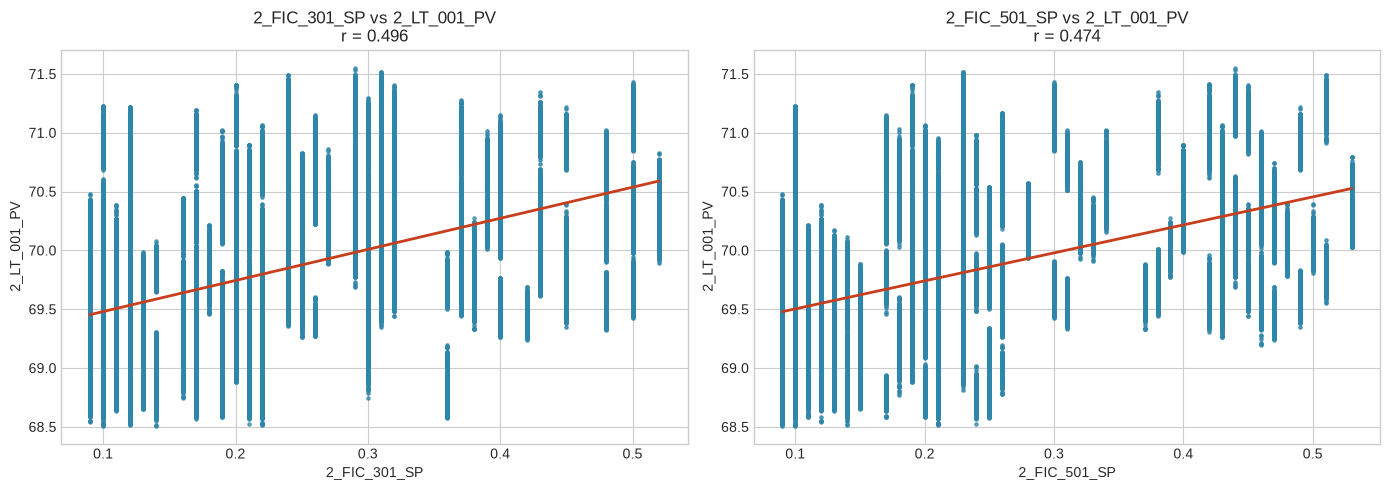

In [13]:
# Scatter plots : top 2 variables corrélées vs target
top2 = top_corr["Variable"].head(2).tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var in zip(axes, top2):
    x = df[var]
    y = df[TARGET]
    ax.scatter(x, y, alpha=0.2, s=5, color=COLORS["primary"])
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_sorted = np.sort(x)
    ax.plot(x_sorted, p(x_sorted), color=COLORS["danger"], linewidth=2)
    r = correlations[var]
    ax.set_xlabel(var)
    ax.set_ylabel(TARGET)
    ax.set_title(f"{var} vs {TARGET}\nr = {r:.3f}")

plt.tight_layout()
plt.show()

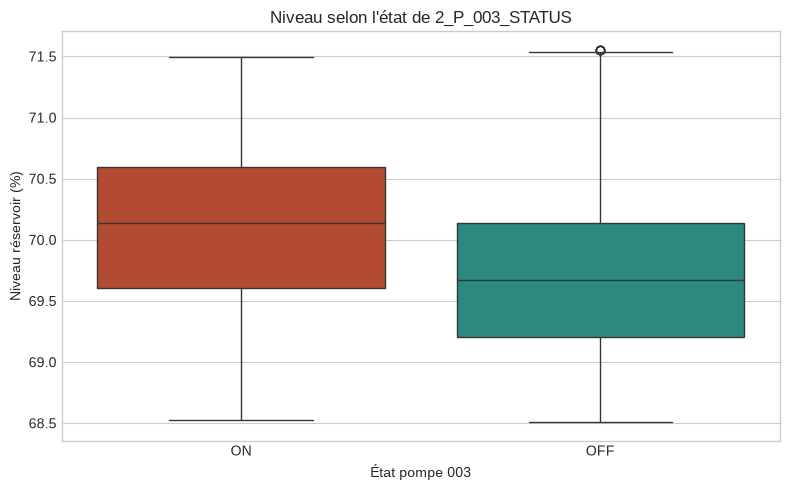

In [14]:
# Effet de l'état de la pompe sur le niveau
pump_col = "2_P_003_STATUS"
if pump_col in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    pump_labels = df[pump_col].map({1: "OFF", 2: "ON"}).fillna("Autre")
    sns.boxplot(x=pump_labels, y=df[TARGET], hue=pump_labels, palette=[COLORS["danger"], COLORS["success"]], dodge=False, legend=False, ax=ax)
    ax.set_xlabel("État pompe 003")
    ax.set_ylabel("Niveau réservoir (%)")
    ax.set_title(f"Niveau selon l'état de {pump_col}")
    plt.tight_layout()
    plt.show()

Les familles **LT, FIT, P, MV, PIT** ressortent en tête des corrélations — elles guideront la sélection des features à l'étape suivante.

## 4. Feature Engineering

On garde les variables les plus corrélées et on crée leur historique récent (lags).

| Modèle | Variables utilisées |
|--------|---------------------|
| Persistence | `TARGET` à l'instant t (niveau actuel) |
| Random Forest | Toutes les `PRIORITY_FEATURES` laggées (1, 2, 5, 10 min) |
| XGBoost | Idem Random Forest |

### De l'instant t à la prédiction t+10

À chaque minute t, le modèle voit l'historique récent (lags) et doit prédire le niveau à t+10 minutes.


In [15]:
# Sélection des variables prioritaires par corrélation
CORR_THRESHOLD = 0.3
priority_vars = correlations[correlations.abs() > CORR_THRESHOLD].index.tolist()
PRIORITY_FEATURES = list(dict.fromkeys([TARGET] + priority_vars))

print(f"Seuil de corrélation : {CORR_THRESHOLD}")
print(f"Variables prioritaires sélectionnées : {len(PRIORITY_FEATURES)}")
print(PRIORITY_FEATURES)

df_model = df.copy()

# Features laggées
for col in PRIORITY_FEATURES:
    for lag in LAGS:
        df_model[f"{col}_lag_{lag}"] = df_model[col].shift(lag)

# Target : niveau dans HORIZON minutes
df_model["target"] = df_model[TARGET].shift(-HORIZON)

# Supprimer les lignes avec NaN
lag_cols = [c for c in df_model.columns if "_lag_" in c]
df_model = df_model.dropna(subset=lag_cols + ["target"]).reset_index(drop=True)

feature_cols = lag_cols
print(f"\nDataset modèle: {df_model.shape[0]:,} lignes × {len(feature_cols)} features")

Seuil de corrélation : 0.3
Variables prioritaires sélectionnées : 13
['2_LT_001_PV', '2_FIC_301_SP', '2_FIC_501_SP', '1_AIT_001_PV', '1_AIT_002_PV', '2_FIC_401_SP', '2A_AIT_001_PV', '2_FIC_601_SP', '2_FIC_101_SP', '1_AIT_003_PV', '2_FIC_201_SP', '2_P_004_SPEED', '2B_AIT_001_PV']

Dataset modèle: 784,551 lignes × 52 features


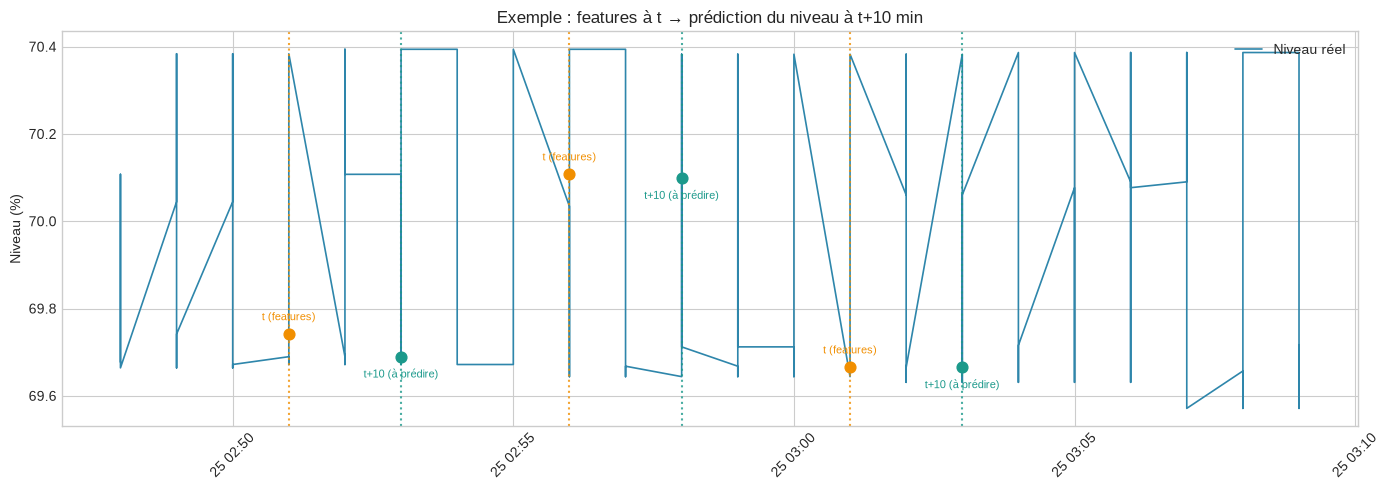

In [16]:
# Illustration : à l'instant t, on prédit le niveau à t+10 minutes
sample_start = 1000
sample_len = 2 * 60  # 2 heures
sample = df_model.iloc[sample_start : sample_start + sample_len + HORIZON]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample["datetime"], sample[TARGET], color=COLORS["primary"], linewidth=1.2, label="Niveau réel")

# Marquer 3 paires (t, t+10)
for offset in [20, 50, 80]:
    t_idx = offset
    if t_idx + HORIZON >= len(sample):
        continue
    t_time = sample["datetime"].iloc[t_idx]
    t_plus_time = sample["datetime"].iloc[t_idx + HORIZON]
    t_val = sample[TARGET].iloc[t_idx]
    target_val = sample["target"].iloc[t_idx]

    ax.axvline(t_time, color=COLORS["warning"], linestyle=":", alpha=0.8)
    ax.axvline(t_plus_time, color=COLORS["success"], linestyle=":", alpha=0.8)
    ax.scatter([t_time], [t_val], color=COLORS["warning"], s=60, zorder=5)
    ax.scatter([t_plus_time], [target_val], color=COLORS["success"], s=60, zorder=5)
    ax.annotate(
        "t (features)",
        (t_time, t_val),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8,
        color=COLORS["warning"],
    )
    ax.annotate(
        "t+10 (à prédire)",
        (t_plus_time, target_val),
        textcoords="offset points",
        xytext=(0, -15),
        ha="center",
        fontsize=8,
        color=COLORS["success"],
    )

ax.set_ylabel("Niveau (%)")
ax.set_title(f"Exemple : features à t → prédiction du niveau à t+{HORIZON} min")
ax.legend(["Niveau réel"], loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Modélisation Prédictive

On découpe les données dans le temps, puis on entraîne 3 modèles à comparer.

**Split temporel 80/20** — pas de shuffle aléatoire, on respecte l'ordre chronologique.

In [17]:
split_idx = int(len(df_model) * TRAIN_RATIO)

X = df_model[feature_cols]
y = df_model["target"]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 627,640 | Test: 156,911


In [18]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"Modèle": name, "MAE": mae, "RMSE": rmse}

results = []

# --- Persistence (baseline) : niveau actuel à t → même valeur à t+10 ---
y_pred_persist = pd.Series(
    df_model[TARGET].iloc[split_idx:].values,
    index=y_test.index,
    name="Persistence",
)
results.append(evaluate(y_test, y_pred_persist, "Persistence"))

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(evaluate(y_test, y_pred_rf, "Random Forest"))

# --- XGBoost ---
try:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    results.append(evaluate(y_test, y_pred_xgb, "XGBoost"))
except ImportError:
    print("XGBoost non installé — pip install xgboost")

print("Entraînement terminé.")

Entraînement terminé.


## 6. Évaluation

1. **6.1** — Tableau MAE / RMSE (comparaison globale)
2. **6.2** — Tableau prédictions minute par minute
3. **6.3** — Graphiques (scatter + courbe 24 h)


### 6.1 Comparaison globale — MAE et RMSE


       Modèle      MAE     RMSE  Amélioration % vs Persistence
  Persistence 0.607644 0.757785                            0.0
Random Forest 0.499340 0.541197                           28.6
      XGBoost 0.502245 0.547401                           27.8


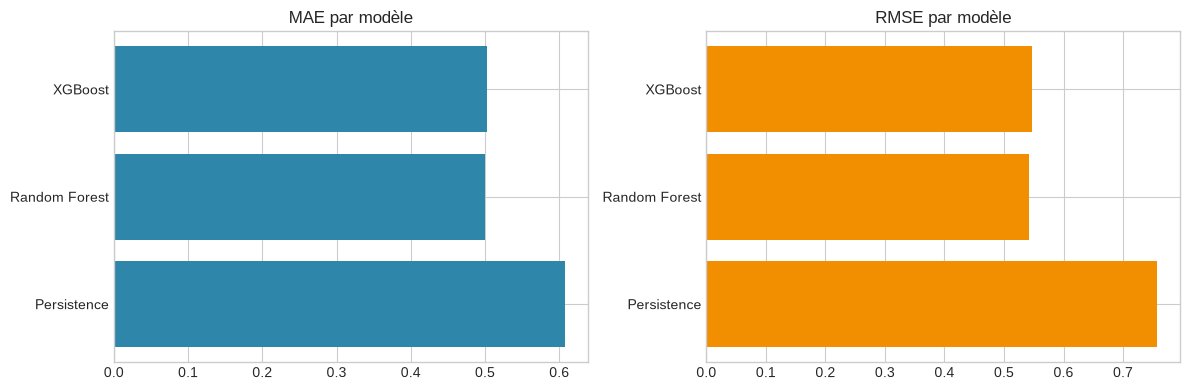

In [19]:
results_df = pd.DataFrame(results)
rmse_persist = results_df.loc[results_df["Modèle"] == "Persistence", "RMSE"].values[0]
results_df["Amélioration % vs Persistence"] = (
    (1 - results_df["RMSE"] / rmse_persist) * 100
).round(1)

print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(results_df["Modèle"], results_df["MAE"], color=COLORS["primary"])
axes[0].set_title("MAE par modèle")
axes[1].barh(results_df["Modèle"], results_df["RMSE"], color=COLORS["warning"])
axes[1].set_title("RMSE par modèle")
plt.tight_layout()
plt.show()

### 6.2 Tableau prédictions — `2_LT_001_PV` à +10 min

Pour chaque minute du test : niveau à **t**, niveau réel à **t+10**, et prédictions de chaque modèle.


In [20]:
# Tableau comparatif : réel vs chaque modèle (aperçu)
PREVIEW_ROWS = 20

level_at_t = df_model[TARGET].iloc[split_idx : split_idx + len(y_test)].values

comparison = pd.DataFrame({
    "datetime (t)": df_model["datetime"].iloc[split_idx : split_idx + len(y_test)].values,
    f"{TARGET} à t": level_at_t,
    f"{TARGET} réel (t+{HORIZON})": y_test.values,
    "Persistence": y_pred_persist.values,
    "Random Forest": y_pred_rf,
})

try:
    comparison["XGBoost"] = y_pred_xgb
except NameError:
    pass

comparison["Erreur RF"] = (
    comparison["Random Forest"] - comparison[f"{TARGET} réel (t+{HORIZON})"]
).round(3)

print("=" * 70)
print(f"PRÉDICTIONS — {TARGET} à horizon +{HORIZON} min (jeu de test)")
print("=" * 70)
print(f"Total lignes test : {len(comparison):,}")
print(f"Aperçu des {PREVIEW_ROWS} premières minutes :\n")
display(comparison.head(PREVIEW_ROWS).round(3))

ex = comparison.iloc[0]
print(f"\nExemple : {TARGET} = {ex[f'{TARGET} à t']:.2f} % à t  →  réel à t+{HORIZON} = {ex[f'{TARGET} réel (t+{HORIZON})']:.2f} %")
print(f"  Persistence = {ex['Persistence']:.2f} % | RF = {ex['Random Forest']:.2f} %", end="")
if "XGBoost" in comparison.columns:
    print(f" | XGBoost = {ex['XGBoost']:.2f} %")
else:
    print()


PRÉDICTIONS — 2_LT_001_PV à horizon +10 min (jeu de test)
Total lignes test : 156,911
Aperçu des 20 premières minutes :



,datetime (t),2_LT_001_PV à t,2_LT_001_PV réel (t+10),Persistence,Random Forest,XGBoost,Erreur RF
0,2017-10-06 20:06:00,69.204,70.048,69.204,69.647,69.544998,-0.401
1,2017-10-06 20:06:00,70.453,70.046,70.453,69.569,69.570000,-0.476
2,2017-10-06 20:06:00,70.174,69.464,70.174,69.713,69.575996,0.249
3,2017-10-06 20:06:00,69.542,69.182,69.542,69.595,69.704002,0.414
4,2017-10-06 20:06:00,69.234,70.376,69.234,69.576,69.610001,-0.800
5,2017-10-06 20:06:00,69.287,69.266,69.287,69.640,69.586998,0.375
6,2017-10-06 20:06:00,69.211,69.868,69.211,69.333,69.434998,-0.534
7,2017-10-06 20:06:00,69.057,70.217,69.057,69.541,69.633003,-0.677
8,2017-10-06 20:06:00,69.109,69.906,69.109,69.648,69.623001,-0.258
9,2017-10-06 20:06:00,69.257,69.445,69.257,69.540,69.554001,0.095



Exemple : 2_LT_001_PV = 69.20 % à t  →  réel à t+10 = 70.05 %
  Persistence = 69.20 % | RF = 69.65 % | XGBoost = 69.55 %


### 6.3 Graphiques — scatter et courbe 24 h


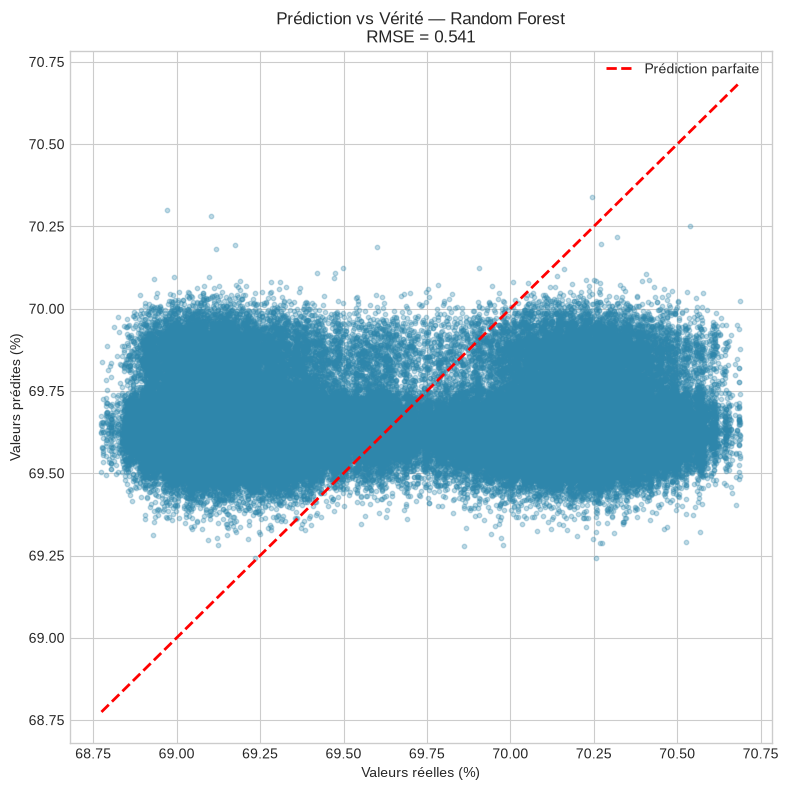

In [21]:
# Meilleur modèle (hors Persistence)
best_row = results_df[results_df["Modèle"] != "Persistence"].sort_values("RMSE").iloc[0]
best_name = best_row["Modèle"]

if best_name == "Random Forest":
    y_pred_best = y_pred_rf
    best_model = rf
elif best_name == "XGBoost":
    y_pred_best = y_pred_xgb
    best_model = xgb
else:
    y_pred_best = y_pred_rf
    best_model = rf

# Scatter : prédiction vs vérité
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_best, alpha=0.3, s=10, color=COLORS["primary"])
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, "r--", linewidth=2, label="Prédiction parfaite")
ax.set_xlabel("Valeurs réelles (%)")
ax.set_ylabel("Valeurs prédites (%)")
ax.set_title(f"Prédiction vs Vérité — {best_name}\nRMSE = {best_row['RMSE']:.3f}")
ax.legend()
plt.tight_layout()
plt.show()

On trace le niveau réel et les prédictions sur une fenêtre du jeu de test.

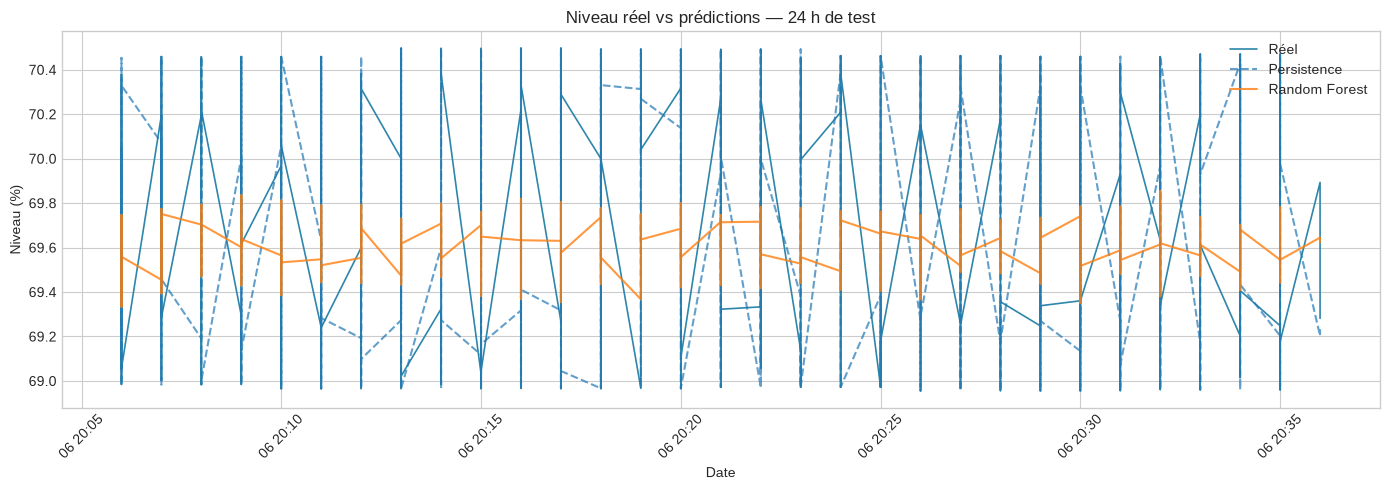

In [22]:
# Courbe temporelle : réel vs prédictions (24 h de test)
window = min(24 * 60, len(y_test))
times = df_model["datetime"].iloc[split_idx : split_idx + window]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(times, y_test.iloc[:window].values, label="Réel", color=COLORS["primary"], linewidth=1.2)
ax.plot(times, y_pred_persist.iloc[:window].values, label="Persistence", alpha=0.7, linestyle="--")
ax.plot(times, y_pred_best[:window], label=best_name, alpha=0.8)
ax.set_ylabel("Niveau (%)")
ax.set_xlabel("Date")
ax.set_title("Niveau réel vs prédictions — 24 h de test")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Conclusions

Objectif du projet : prédire **`2_LT_001_PV` dans 10 minutes**.

- Copier les tableaux MAE/RMSE et prédictions dans [`docs/rapport/resultats.md`](docs/rapport/resultats.md)
- Compléter le rapport et cocher « Compréhension validée » dans [`docs/design_doc.md`](docs/design_doc.md)


In [23]:
import os
import joblib

os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/best_model.pkl")

print(f"Modèle sauvegardé: models/best_model.pkl ({best_name})")
print(f"RMSE: {best_row['RMSE']:.4f} | Amélioration vs Persistence: {best_row['Amélioration % vs Persistence']:.1f}%")

Modèle sauvegardé: models/best_model.pkl (Random Forest)
RMSE: 0.5412 | Amélioration vs Persistence: 28.6%
